# Cardiac EDA
Exploratory analysis of the cardiac datasets with pipeline-aligned data stages and consistent comparisons.

## Imports
Load required libraries for data handling, plotting, and lightweight statistics.

In [1]:
from __future__ import annotations
from pathlib import Path
import sys
import json
import warnings
import yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ks_2samp
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)
sns.set_theme(style="whitegrid")

## Paths and configuration
Define project paths, load pipeline config, and set shared color mappings.

In [2]:
ROOT_DIR = Path.cwd().resolve()
if (ROOT_DIR / "configs").exists() is False:
    ROOT_DIR = ROOT_DIR.parents[0]
sys.path.append(str(ROOT_DIR / "src"))
DATA_DIR = ROOT_DIR / "data" / "cardiac"
RESULTS_DIR = ROOT_DIR / "results" / "cardiac"
CONFIG_DIR = ROOT_DIR / "configs"

PIPELINE_CFG_PATH = CONFIG_DIR / "pipelines" / "cardiac.yaml"
FEATURE_MAP_PATH = CONFIG_DIR / "domain" / "cardiac_feature_map.yaml"
SCHEMA_PATH = CONFIG_DIR / "schema" / "cardiac.json"

with open(PIPELINE_CFG_PATH, "r") as f:
    pipeline_cfg = yaml.safe_load(f)

with open(FEATURE_MAP_PATH, "r") as f:
    feature_map = yaml.safe_load(f)

with open(SCHEMA_PATH, "r") as f:
    schema_cfg = json.load(f)

EXTERNAL_DIR = ROOT_DIR / pipeline_cfg["paths"]["external_dir"]
RAW_DIR = ROOT_DIR / pipeline_cfg["paths"]["raw_dir"]
PROCESSED_DIR = ROOT_DIR / pipeline_cfg["paths"]["processed_dir"]

DATASETS = schema_cfg.get("cardiac_relevant_datasets", ["cleveland", "kaggle_heart", "cardio70k"])
PRIMARY_DATASETS = ["cleveland", "kaggle_heart"]
TARGET_COL = feature_map["target"]["heart_disease"]["canonical"]
SENSITIVE_COL = feature_map["sensitive"]["sex"]["canonical"]

ROOT_DIR, DATA_DIR, RESULTS_DIR

(PosixPath('/home/miguel/Desktop/Dissertacao/Code/FairXAI'),
 PosixPath('/home/miguel/Desktop/Dissertacao/Code/FairXAI/data/cardiac'),
 PosixPath('/home/miguel/Desktop/Dissertacao/Code/FairXAI/results/cardiac'))

## Helper utilities
Shared helpers for CSV loading, labeling, and unit-aware conversions used throughout the notebook.

In [3]:
from fairxai import notebook_utils as nb_utils
from fairxai.notebook_utils import (
    PALETTE_DATASET,
    PALETTE_SEX,
    PALETTE_TARGET,
    UNITS,
    detect_csv_sep,
    dataset_age_unit,
    age_group_order,
    apply_age_group_order,
    age_to_years,
    resolve_sex_series,
    add_bar_labels,
    add_bar_labels_with_counts,
    add_grouped_bar_labels,
    add_point_labels,
 )

nb_utils.set_schema_cfg(schema_cfg)

## Pipeline overview
Summarize how data moves from external sources to standardized raw and processed splits.

External data is standardized into raw datasets (canonical schema), then preprocessed into train/test splits with scaling and metadata outputs.

Preprocessing steps used in the pipeline: missing-value handling, stratified train/test split, scaling, and per-dataset metadata outputs.

## Load external, raw, and processed datasets
Read each dataset in its lifecycle stages to enable before/after comparisons.

In [4]:
EXTERNAL_FILES = {
    "cleveland": EXTERNAL_DIR / "heart_cleveland_upload.csv",
    "kaggle_heart": EXTERNAL_DIR / "heart.csv",
    "cardio70k": EXTERNAL_DIR / "cardio_train.csv",
}

def load_external():
    loaded = {}
    for name, path in EXTERNAL_FILES.items():
        sep = detect_csv_sep(path)
        loaded[name] = pd.read_csv(path, sep=sep)
    return loaded

def load_raw():
    return {name: pd.read_csv(RAW_DIR / f"{name}_standardized.csv") for name in DATASETS}

def load_processed_scaled():
    processed = {}
    for name in DATASETS:
        base = PROCESSED_DIR / name
        train_path = base / f"{name}_train_scaled.csv"
        test_path = base / f"{name}_test_scaled.csv"
        if train_path.exists() and test_path.exists():
            processed[name] = {
                "train": pd.read_csv(train_path),
                "test": pd.read_csv(test_path),
            }
    return processed

external = load_external()
raw = load_raw()
processed = load_processed_scaled()

print("\nDataset shapes across formats:")
for name in DATASETS:
    ext_shape = external[name].shape if name in external else "N/A"
    raw_shape = raw[name].shape if name in raw else "N/A"
    proc_train_shape = processed[name]["train"].shape if name in processed else "N/A"
    proc_test_shape = processed[name]["test"].shape if name in processed else "N/A"
    print(f"{name}: External={ext_shape}, Raw={raw_shape}, Processed Train={proc_train_shape}, Processed Test={proc_test_shape}")


Dataset shapes across formats:
cleveland: External=(297, 14), Raw=(297, 17), Processed Train=(206, 16), Processed Test=(89, 16)
kaggle_heart: External=(918, 12), Raw=(918, 15), Processed Train=(641, 14), Processed Test=(276, 14)
cardio70k: External=(70000, 13), Raw=(70000, 15), Processed Train=(49000, 12), Processed Test=(21000, 12)


## Cardio70k sanity check (external/raw/processed)
Lightweight checks to validate age units, basic ranges, and preprocessing availability before profiling.

In [5]:
cardio_ext = external.get("cardio70k")
cardio_raw = raw.get("cardio70k")
cardio_proc = processed.get("cardio70k")

sanity_rows = []
if cardio_ext is not None:
    sanity_rows.append({
        "stage": "external",
        "rows": len(cardio_ext),
        "cols": len(cardio_ext.columns),
        "missing_cells": int(cardio_ext.isna().sum().sum()),
    })
if cardio_raw is not None:
    sanity_rows.append({
        "stage": "raw",
        "rows": len(cardio_raw),
        "cols": len(cardio_raw.columns),
        "missing_cells": int(cardio_raw.isna().sum().sum()),
    })
if cardio_proc is not None:
    sanity_rows.append({
        "stage": "processed",
        "rows": len(cardio_proc.get("train", [])) + len(cardio_proc.get("test", [])),
        "cols": len(cardio_proc.get("train", [])) if cardio_proc.get("train") is not None else None,
        "missing_cells": int(cardio_proc.get("train", pd.DataFrame()).isna().sum().sum()) + int(cardio_proc.get("test", pd.DataFrame()).isna().sum().sum()),
    })
display(pd.DataFrame(sanity_rows))

if cardio_raw is not None and "age_raw" in cardio_raw.columns:
    unit = dataset_age_unit("cardio70k")
    age_years = age_to_years(cardio_raw["age_raw"], unit)
    age_summary = {
        "unit": unit,
        "age_raw_min": float(cardio_raw["age_raw"].min()),
        "age_raw_max": float(cardio_raw["age_raw"].max()),
        "age_years_min": float(age_years.min()),
        "age_years_max": float(age_years.max()),
        "age_years_mean": float(age_years.mean()),
    }
    display(pd.DataFrame([age_summary]))

    outlier_checks = []
    if {"ap_hi", "ap_lo"}.issubset(cardio_raw.columns):
        outlier_checks.append({
            "feature": "ap_hi",
            "low": int((cardio_raw["ap_hi"] < 60).sum()),
            "high": int((cardio_raw["ap_hi"] > 250).sum()),
        })
        outlier_checks.append({
            "feature": "ap_lo",
            "low": int((cardio_raw["ap_lo"] < 40).sum()),
            "high": int((cardio_raw["ap_lo"] > 150).sum()),
        })
    if {"height", "weight"}.issubset(cardio_raw.columns):
        outlier_checks.append({
            "feature": "height",
            "low": int((cardio_raw["height"] < 130).sum()),
            "high": int((cardio_raw["height"] > 210).sum()),
        })
        outlier_checks.append({
            "feature": "weight",
            "low": int((cardio_raw["weight"] < 40).sum()),
            "high": int((cardio_raw["weight"] > 180).sum()),
        })
    if outlier_checks:
        display(pd.DataFrame(outlier_checks))

,stage,rows,cols,missing_cells
0,external,70000,13,0
1,raw,70000,15,0
2,processed,70000,49000,0


,unit,age_raw_min,age_raw_max,age_years_min,age_years_max,age_years_mean
0,days,10798.0,23713.0,29.563313,64.922656,53.30285


,feature,low,high
0,ap_hi,188,40
1,ap_lo,59,975
2,height,92,1
3,weight,52,4


## Data quality and cleaning impact
Compare external vs raw to quantify row drops and missingness.

In [6]:
def summarize_stage(dfs, stage):
    rows = []
    for name, df in dfs.items():
        rows.append({
            "dataset": name,
            "stage": stage,
            "rows": len(df),
            "cols": len(df.columns),
            "missing_cells": int(df.isna().sum().sum()),
            "rows_with_missing": int(df.isna().any(axis=1).sum()),
        })
    return pd.DataFrame(rows)

summary_external = summarize_stage(external, "external")
summary_raw = summarize_stage(raw, "raw")
cleaning_summary = summary_external.merge(summary_raw, on="dataset", suffixes=("_external", "_raw"))
cleaning_summary["rows_removed"] = cleaning_summary["rows_external"] - cleaning_summary["rows_raw"]
cleaning_summary["pct_removed"] = (cleaning_summary["rows_removed"] / cleaning_summary["rows_external"]).round(4)
cleaning_summary[["dataset", "rows_external", "rows_raw", "rows_removed", "pct_removed", "rows_with_missing_external"]]

,dataset,rows_external,rows_raw,rows_removed,pct_removed,rows_with_missing_external
0,cleveland,297,297,0,0.0,0
1,kaggle_heart,918,918,0,0.0,0
2,cardio70k,70000,70000,0,0.0,0


**Note:** The external Cleveland file used here (297 rows) has already been cleaned.

The original UCI Cleveland dataset had 303 rows; 6 were removed due to missing values in 'ca' and 'thal' columns during initial data preparation.

## Feature schema comparison (canonical mapping)
Use the YAML feature map to compare canonical features rather than raw column names.

In [7]:
def canonical_features_for_columns(columns: list[str], dataset_name: str) -> set[str]:
    canonical = set()

    def add_from_section(section: dict) -> None:
        for _, info in section.items():
            canonical_name = info.get("canonical")
            aliases = info.get("aliases", [])
            candidates = [canonical_name] + aliases if canonical_name else aliases
            if any(col in columns for col in candidates):
                if canonical_name:
                    canonical.add(canonical_name)

    for group in ("sensitive", "common", "target"):
        add_from_section(feature_map.get(group, {}))

    dataset_specific = feature_map.get("dataset_specific", {}).get(dataset_name, {})
    add_from_section(dataset_specific)
    return canonical

canonical_by_dataset = {}
for name, df in raw.items():
    canonical_by_dataset[name] = sorted(canonical_features_for_columns(df.columns, name))
    print(f"\n{name} canonical features ({len(canonical_by_dataset[name])}):")
    print(canonical_by_dataset[name])

shared_all = set.intersection(*[set(v) for v in canonical_by_dataset.values()])
primary_sets = [set(canonical_by_dataset[name]) for name in PRIMARY_DATASETS if name in canonical_by_dataset]
shared_primary = set.intersection(*primary_sets) if primary_sets else set()
unique_canonical = {
    name: sorted(set(feats) - shared_all) for name, feats in canonical_by_dataset.items()
}

print(f"\nShared canonical features across all datasets ({len(shared_all)}):")
print(sorted(shared_all))
print(f"Shared canonical features across primary datasets only ({len(shared_primary)}):")
print(sorted(shared_primary))
for name, feats in unique_canonical.items():
    print(f"{name} unique canonical features ({len(feats)}): {feats}")


cleveland canonical features (14):
['age_raw', 'ca', 'chol', 'cp', 'exang', 'fbs', 'heart_disease', 'oldpeak', 'restecg', 'sex', 'slope', 'thal', 'thalach', 'trestbps']

kaggle_heart canonical features (12):
['age_raw', 'chol', 'cp', 'exang', 'fbs', 'heart_disease', 'oldpeak', 'restecg', 'sex', 'slope', 'thalach', 'trestbps']

cardio70k canonical features (12):
['active', 'age_raw', 'alco', 'ap_hi', 'ap_lo', 'cholesterol', 'gluc', 'heart_disease', 'height', 'sex', 'smoke', 'weight']

Shared canonical features across all datasets (3):
['age_raw', 'heart_disease', 'sex']
Shared canonical features across primary datasets only (12):
['age_raw', 'chol', 'cp', 'exang', 'fbs', 'heart_disease', 'oldpeak', 'restecg', 'sex', 'slope', 'thalach', 'trestbps']
cleveland unique canonical features (11): ['ca', 'chol', 'cp', 'exang', 'fbs', 'oldpeak', 'restecg', 'slope', 'thal', 'thalach', 'trestbps']
kaggle_heart unique canonical features (9): ['chol', 'cp', 'exang', 'fbs', 'oldpeak', 'restecg', 'slo

**Note:** Cleveland is a subset inside the Kaggle Heart compilation; Cardio70k follows a different schema.

## Sensitive attribute analysis: age
Compare age distributions with unit awareness across datasets.

In [8]:
age_units = []
for name, df in raw.items():
    unit = dataset_age_unit(name)
    age_units.append({"dataset": name, "age_unit": unit})
pd.DataFrame(age_units)

,dataset,age_unit
0,cleveland,years
1,kaggle_heart,years
2,cardio70k,days


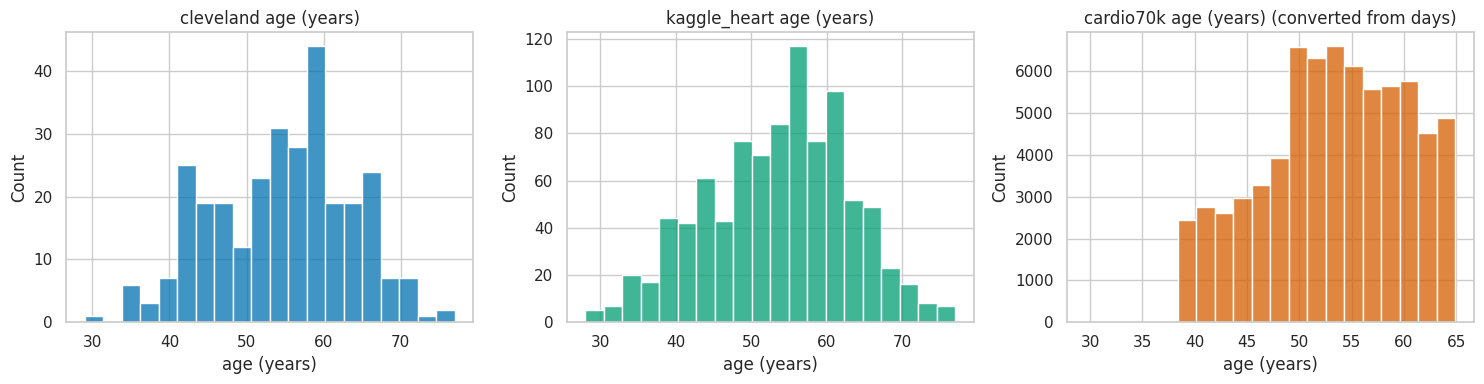

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, name in enumerate(DATASETS):
    df = raw[name]
    unit = dataset_age_unit(name)
    age_years = age_to_years(df["age_raw"], unit)
    sns.histplot(age_years, bins=20, ax=axes[idx], color=PALETTE_DATASET.get(name, "#4c72b0"))
    suffix = " (converted from days)" if unit == "days" else ""
    axes[idx].set_title(f"{name} age (years){suffix}")
    axes[idx].set_xlabel("age (years)")
plt.tight_layout()

### Age groups (raw standardized)
Compare standardized age_group distributions for each dataset.

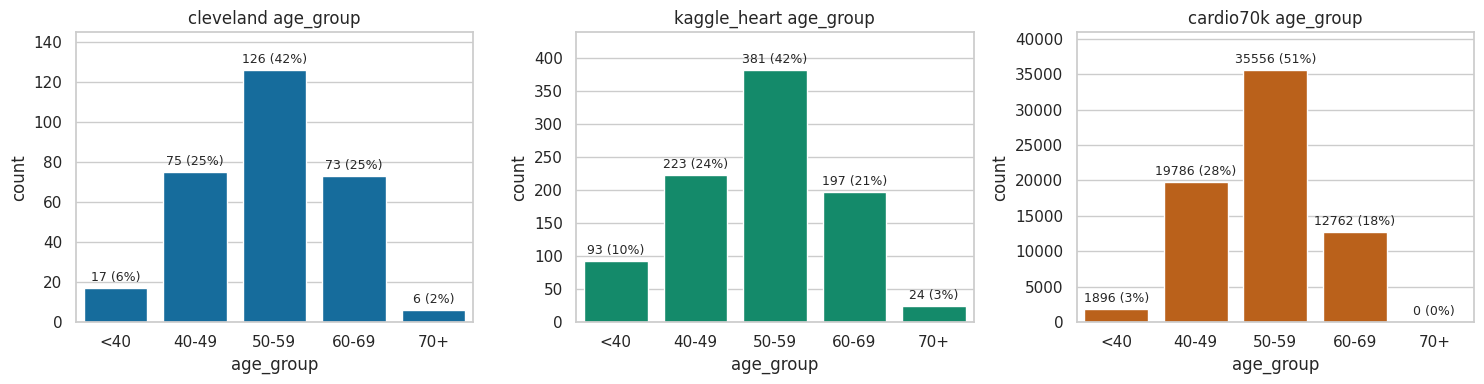

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
counts_by_dataset = {}
for name in DATASETS:
    df = raw[name]
    if "age_group" in df.columns:
        order = age_group_order(name)
        counts = df["age_group"].astype(str).value_counts().reindex(order, fill_value=0)
        counts_by_dataset[name] = counts

for idx, name in enumerate(DATASETS):
    df = raw[name]
    if "age_group" not in df.columns:
        axes[idx].set_title(f"{name} (missing age_group)")
        continue
    counts = counts_by_dataset[name]
    sns.barplot(x=counts.index.astype(str), y=counts.values, ax=axes[idx], color=PALETTE_DATASET.get(name, "#4c72b0"))
    axes[idx].set_title(f"{name} age_group")
    axes[idx].set_xlabel("age_group")
    axes[idx].set_ylabel("count")
    axes[idx].set_ylim(0, counts.max() * 1.15)
    add_bar_labels(ax=axes[idx], total=counts.sum())
plt.tight_layout()

,dataset,age_unit,min,max,mean,median,std
0,cleveland,years,29.000000,77.000000,54.542088,56.000000,9.049736
1,kaggle_heart,years,28.000000,77.000000,53.510893,54.000000,9.432617
2,cardio70k,days,29.563313,64.922656,53.302850,53.943874,6.754967


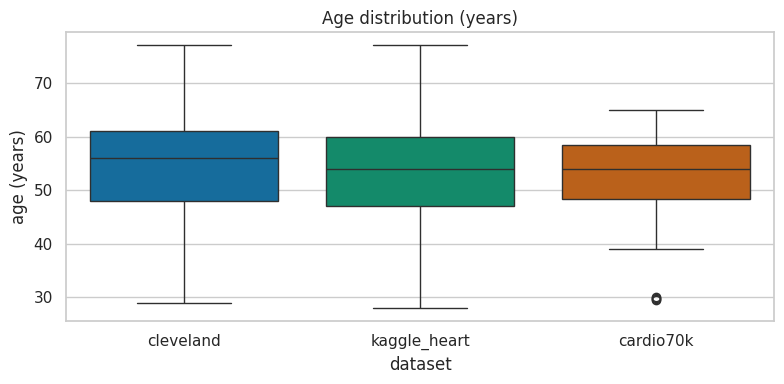

In [11]:
age_stats = []
age_plot_rows = []
for name, df in raw.items():
    unit = dataset_age_unit(name)
    age_years = age_to_years(df["age_raw"], unit)
    age_stats.append({
        "dataset": name,
        "age_unit": unit,
        "min": age_years.min(),
        "max": age_years.max(),
        "mean": age_years.mean(),
        "median": age_years.median(),
        "std": age_years.std(),
    })
    age_plot_rows.append(pd.DataFrame({"dataset": name, "age_years": age_years}))

age_stats_df = pd.DataFrame(age_stats)
age_plot = pd.concat(age_plot_rows, ignore_index=True)
fig, ax = plt.subplots(figsize=(8, 4))
sns.boxplot(data=age_plot, x="dataset", y="age_years", ax=ax, palette=PALETTE_DATASET)
ax.set_title("Age distribution (years)")
ax.set_xlabel("dataset")
ax.set_ylabel("age (years)")
plt.tight_layout()
display(age_stats_df)

## Sensitive attribute analysis: sex
Compare sex encoding and distribution across datasets.

In [12]:
sex_tables = []
for name, df in raw.items():
    series = resolve_sex_series(df)
    if series is None:
        continue
    counts = series.value_counts(dropna=False)
    total = counts.sum()
    for label, value in counts.items():
        sex_tables.append({
            "dataset": name,
            "sex": label,
            "count": int(value),
            "pct": round(value / total, 4),
        })
sex_df = pd.DataFrame(sex_tables)
display(sex_df)

,dataset,sex,count,pct
0,cleveland,Male,201,0.6768
1,cleveland,Female,96,0.3232
2,kaggle_heart,Male,725,0.7898
3,kaggle_heart,Female,193,0.2102
4,cardio70k,Female,45530,0.6504
5,cardio70k,Male,24470,0.3496


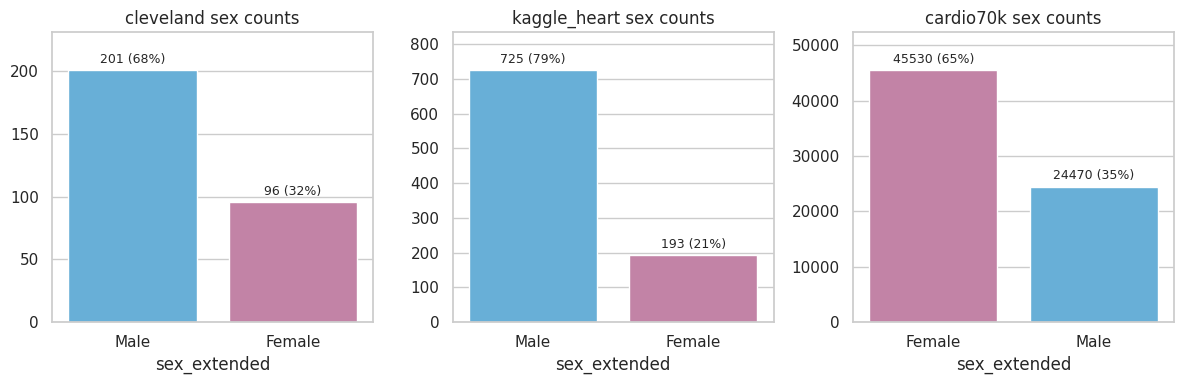

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
counts_by_dataset = {}
for name in DATASETS:
    df = raw[name]
    series = resolve_sex_series(df)
    if series is None:
        continue
    counts = series.value_counts(dropna=False)
    counts_by_dataset[name] = counts

for idx, name in enumerate(DATASETS):
    df = raw[name]
    series = resolve_sex_series(df)
    if series is None:
        axes[idx].set_title(f"{name} (missing sex)")
        continue
    counts = counts_by_dataset[name]
    bar_colors = [PALETTE_SEX.get(str(x), "#7f7f7f") for x in counts.index]
    sns.barplot(x=counts.index.astype(str), y=counts.values, ax=axes[idx], palette=bar_colors)
    axes[idx].set_title(f"{name} sex counts")
    axes[idx].set_ylim(0, counts.max() * 1.15)
    add_bar_labels(ax=axes[idx], total=counts.sum())
plt.tight_layout()

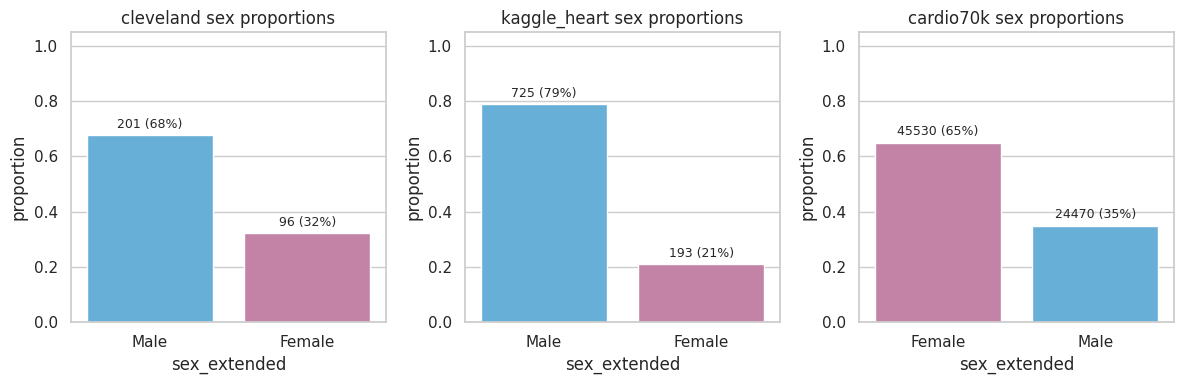

In [14]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for idx, name in enumerate(DATASETS):
    df = raw[name]
    series = resolve_sex_series(df)
    if series is None:
        axes[idx].set_title(f"{name} (missing sex)")
        continue
    counts = series.value_counts(dropna=False)
    prop = counts / counts.sum()
    sns.barplot(
        x=prop.index.astype(str),
        y=prop.values,
        ax=axes[idx],
        palette=[PALETTE_SEX.get(str(x), "#7f7f7f") for x in prop.index],
    )
    axes[idx].set_title(f"{name} sex proportions")
    axes[idx].set_ylabel("proportion")
    axes[idx].set_ylim(0, 1.05)
    add_bar_labels_with_counts(axes[idx], counts)
plt.tight_layout()

## Intersectional view: age group x sex
Compare age-group composition by sex within each dataset.

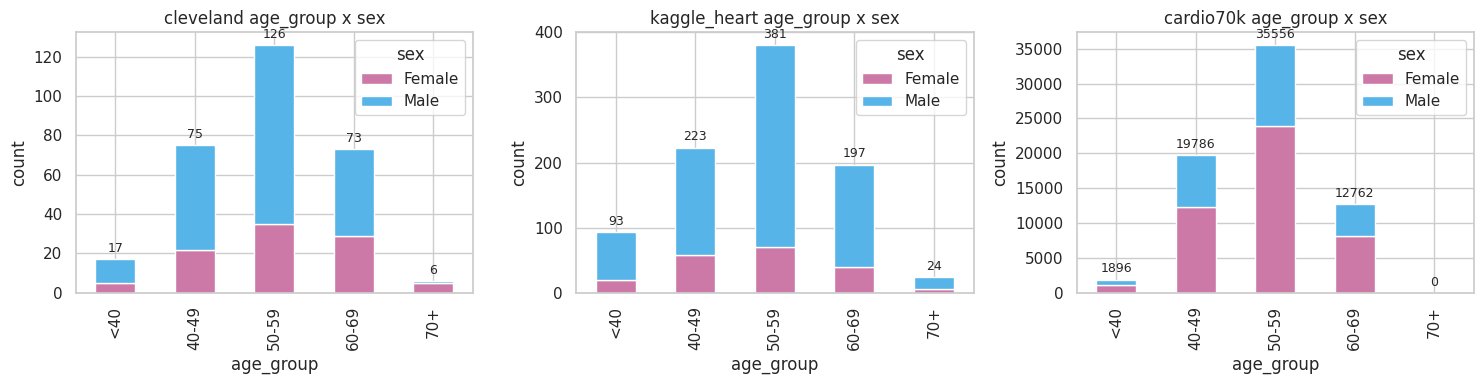

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, name in enumerate(DATASETS):
    df = raw[name]
    series = resolve_sex_series(df)
    if "age_group" not in df.columns or series is None:
        axes[idx].set_title(f"{name} (missing age_group or sex)")
        continue
    age_group = apply_age_group_order(df["age_group"], name)
    temp = pd.DataFrame({"age_group": age_group, "sex": series})
    grouped = temp.groupby(["age_group", "sex"]).size().reset_index(name="count")
    pivoted = grouped.pivot(index="age_group", columns="sex", values="count").fillna(0)
    pivoted = pivoted.reindex(age_group_order(name))
    pivoted.plot(kind="bar", stacked=True, ax=axes[idx], color=[PALETTE_SEX.get(str(c), "#7f7f7f") for c in pivoted.columns])
    totals = pivoted.sum(axis=1)
    for x_pos, total in enumerate(totals):
        axes[idx].annotate(
            f"{int(total)}",
            (x_pos, total),
            ha="center",
            va="bottom",
            fontsize=9,
            xytext=(0, 3),
            textcoords="offset points",
        )
    axes[idx].set_title(f"{name} age_group x sex")
    axes[idx].set_xlabel("age_group")
    axes[idx].set_ylabel("count")
plt.tight_layout()

## Target variable overview
Show heart disease prevalence overall and by sensitive attributes.

In [16]:
target_rows = []
for name, df in raw.items():
    if TARGET_COL in df.columns:
        target_rows.append({"dataset": name, "prevalence": float(df[TARGET_COL].mean())})
pd.DataFrame(target_rows)

,dataset,prevalence
0,cleveland,0.461279
1,kaggle_heart,0.553377
2,cardio70k,0.499700


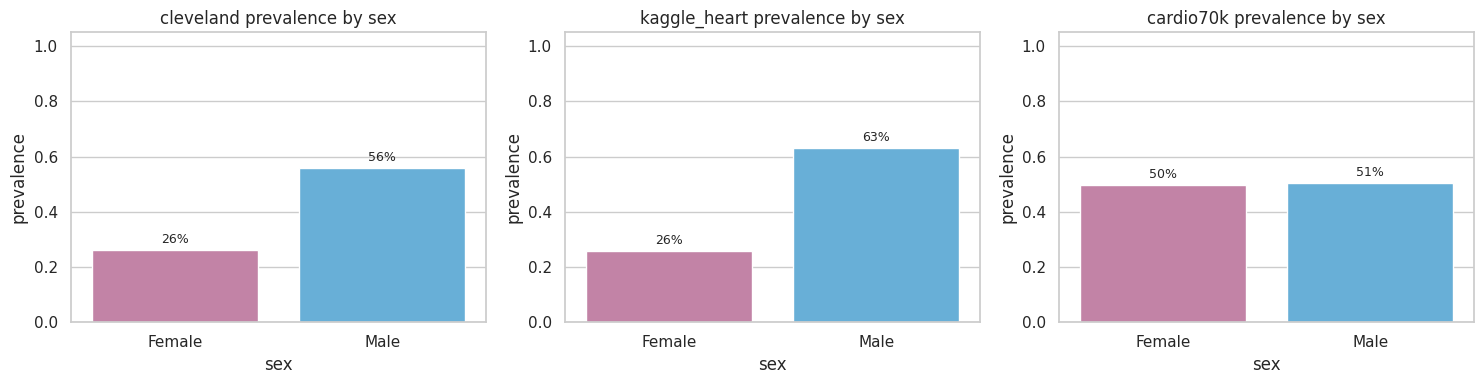

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, name in enumerate(DATASETS):
    df = raw[name]
    series = resolve_sex_series(df)
    if TARGET_COL not in df.columns or series is None:
        axes[idx].set_title(f"{name} (missing target or sex)")
        continue
    temp = pd.DataFrame({"sex": series, TARGET_COL: df[TARGET_COL]})
    grouped = temp.groupby("sex")[TARGET_COL].mean().reset_index()
    sns.barplot(data=grouped, x="sex", y=TARGET_COL, ax=axes[idx], palette=PALETTE_SEX)
    axes[idx].set_title(f"{name} prevalence by sex")
    axes[idx].set_ylabel("prevalence")
    axes[idx].set_ylim(0, 1.05)
    add_bar_labels(ax=axes[idx], total=1, fmt="{pct:.0%}")
plt.tight_layout()

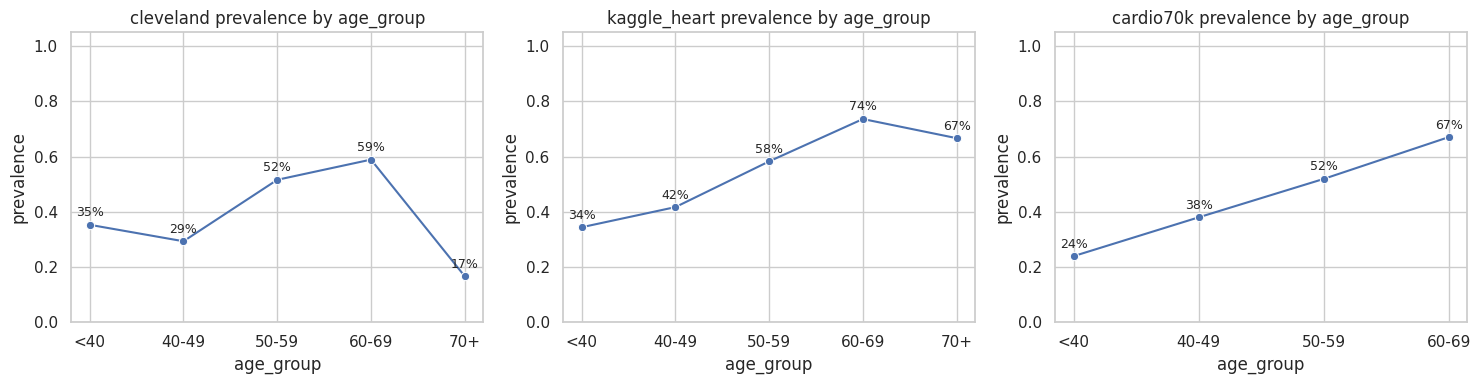

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, name in enumerate(DATASETS):
    df = raw[name]
    if TARGET_COL not in df.columns or "age_group" not in df.columns:
        axes[idx].set_title(f"{name} (missing target or age_group)")
        continue
    age_group = apply_age_group_order(df["age_group"], name)
    temp = pd.DataFrame({"age_group": age_group, TARGET_COL: df[TARGET_COL]})
    grouped = temp.groupby("age_group", observed=True)[TARGET_COL].mean().reset_index()
    sns.lineplot(data=grouped, x="age_group", y=TARGET_COL, ax=axes[idx], marker="o")
    axes[idx].set_title(f"{name} prevalence by age_group")
    axes[idx].set_xlabel("age_group")
    axes[idx].set_ylabel("prevalence")
    axes[idx].set_ylim(0, 1.05)
    add_point_labels(axes[idx], grouped["age_group"], grouped[TARGET_COL])
plt.tight_layout()

## Clinical feature distributions (Cleveland vs Kaggle)
Compare shared clinical features for the two primary datasets.

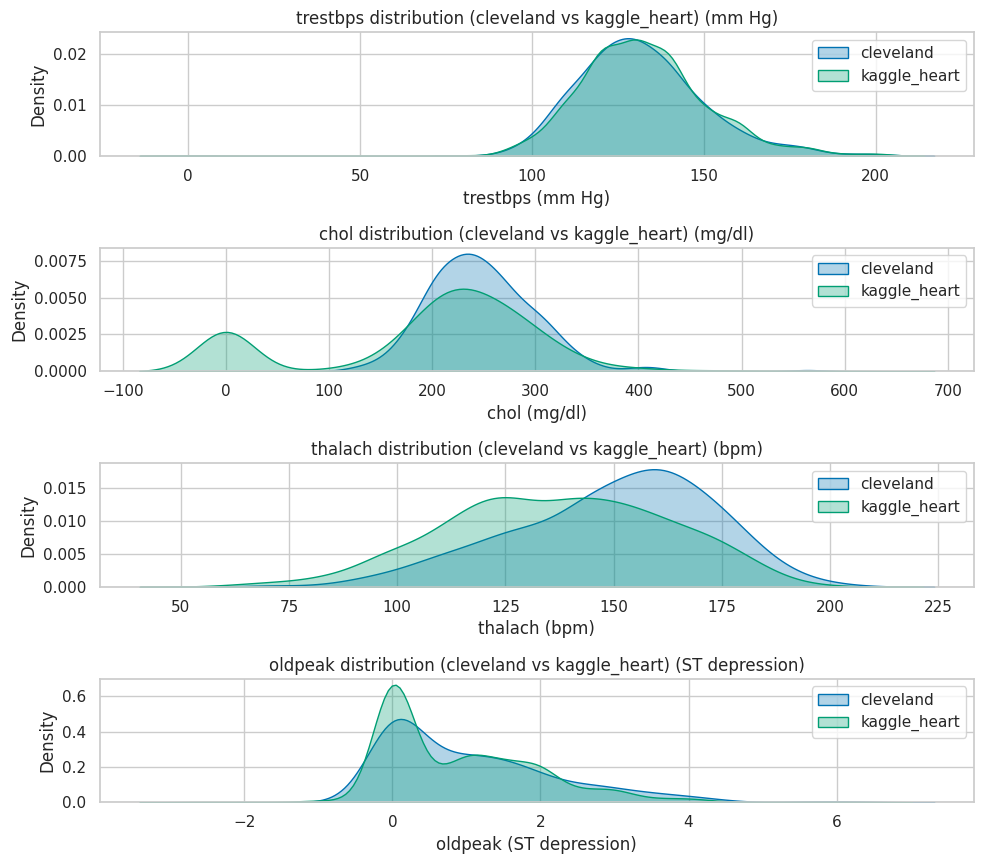

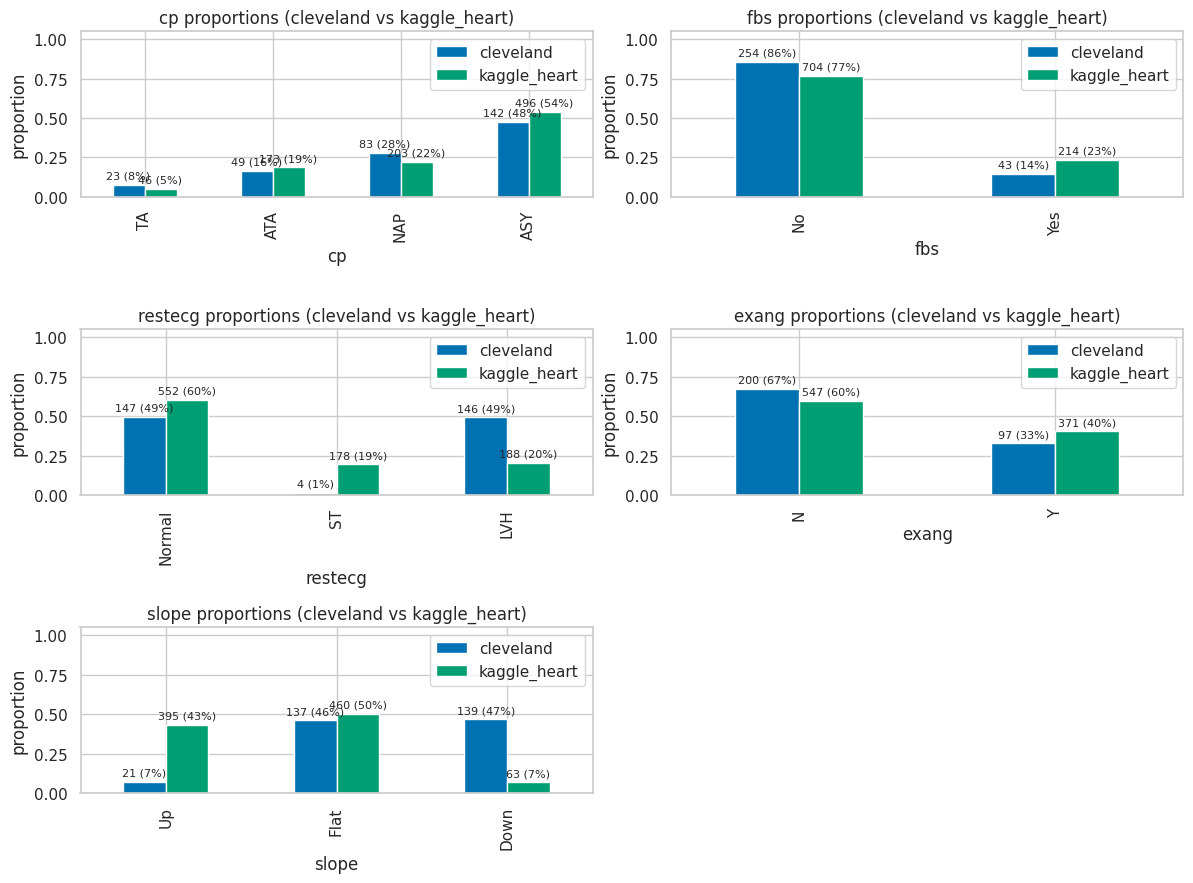

In [19]:
shared_common = [info["canonical"] for info in feature_map.get("common", {}).values()]
cleveland_df = raw["cleveland"]
kaggle_df = raw["kaggle_heart"]

plot_features = [f for f in shared_common if f in cleveland_df.columns and f in kaggle_df.columns]

def numeric_series(df: pd.DataFrame, feature: str) -> pd.Series:
    return pd.to_numeric(df[feature], errors="coerce")

CATEGORY_MAPPINGS = {
    "cp": {"0": "TA", "1": "ATA", "2": "NAP", "3": "ASY", "TA": "TA", "ATA": "ATA", "NAP": "NAP", "ASY": "ASY"},
    "restecg": {"0": "Normal", "1": "ST", "2": "LVH", "Normal": "Normal", "ST": "ST", "LVH": "LVH"},
    "slope": {"0": "Down", "1": "Flat", "2": "Up", "Down": "Down", "Flat": "Flat", "Up": "Up"},
    "exang": {"0": "N", "1": "Y", "N": "N", "Y": "Y"},
    "fbs": {"0": "No", "1": "Yes", "No": "No", "Yes": "Yes"},
}
CATEGORY_ORDER = {
    "cp": ["TA", "ATA", "NAP", "ASY"],
    "restecg": ["Normal", "ST", "LVH"],
    "slope": ["Up", "Flat", "Down"],
    "exang": ["N", "Y"],
    "fbs": ["No", "Yes"],
}

def standardize_category(feature: str, series: pd.Series) -> pd.Series:
    mapping = CATEGORY_MAPPINGS.get(feature)
    if mapping:
        mapped = series.astype(str).map(lambda x: mapping.get(str(x), str(x)))
    else:
        mapped = series.astype(str)
    order = CATEGORY_ORDER.get(feature)
    if order:
        mapped = pd.Categorical(mapped, categories=order, ordered=True)
    return mapped

categorical_features = [f for f in plot_features if f in CATEGORY_MAPPINGS]
numeric_features = [f for f in plot_features if f not in categorical_features]

if numeric_features:
    fig, axes = plt.subplots(len(numeric_features), 1, figsize=(10, max(4, len(numeric_features) * 2.2)))
    if len(numeric_features) == 1:
        axes = [axes]
    for idx, feature in enumerate(numeric_features):
        sns.kdeplot(numeric_series(cleveland_df, feature).dropna(), ax=axes[idx], label="cleveland", color=PALETTE_DATASET["cleveland"], fill=True, alpha=0.3)
        sns.kdeplot(numeric_series(kaggle_df, feature).dropna(), ax=axes[idx], label="kaggle_heart", color=PALETTE_DATASET["kaggle_heart"], fill=True, alpha=0.3)
        unit = UNITS.get(feature)
        title = f"{feature} distribution (cleveland vs kaggle_heart)" + (f" ({unit})" if unit else "")
        axes[idx].set_title(title)
        if unit:
            axes[idx].set_xlabel(f"{feature} ({unit})")
        axes[idx].legend(loc="best")
    plt.tight_layout()
else:
    print("No shared numeric features found for Cleveland vs Kaggle.")

if categorical_features:
    rows = int(np.ceil(len(categorical_features) / 2))
    fig, axes = plt.subplots(rows, 2, figsize=(12, max(4, rows * 3)))
    axes = np.array(axes).reshape(-1)
    for idx, feature in enumerate(categorical_features):
        clev_vals = standardize_category(feature, cleveland_df[feature])
        kag_vals = standardize_category(feature, kaggle_df[feature])
        order = CATEGORY_ORDER.get(feature)
        clev_counts = pd.Series(clev_vals).value_counts()
        kag_counts = pd.Series(kag_vals).value_counts()
        if order:
            clev_counts = clev_counts.reindex(order, fill_value=0)
            kag_counts = kag_counts.reindex(order, fill_value=0)
        counts_df = pd.DataFrame({"cleveland": clev_counts, "kaggle_heart": kag_counts}).fillna(0)
        pct_df = counts_df.div(counts_df.sum(axis=0), axis=1)
        pct_df.plot(kind="bar", ax=axes[idx], color=[PALETTE_DATASET["cleveland"], PALETTE_DATASET["kaggle_heart"]])
        add_grouped_bar_labels(axes[idx], counts_df)
        axes[idx].set_title(f"{feature} proportions (cleveland vs kaggle_heart)")
        axes[idx].set_xlabel(feature)
        axes[idx].set_ylabel("proportion")
        axes[idx].set_ylim(0, 1.05)
    for extra_ax in axes[len(categorical_features):]:
        extra_ax.axis("off")
    plt.tight_layout()

In [20]:
print("\nKolmogorov-Smirnov test results (Cleveland vs Kaggle):")
stat_rows = []
for feature in numeric_features:
    clev_vals = numeric_series(cleveland_df, feature).dropna()
    kag_vals = numeric_series(kaggle_df, feature).dropna()
    if clev_vals.nunique() > 1 and kag_vals.nunique() > 1:
        stat = ks_2samp(clev_vals, kag_vals)
        stat_rows.append({
            "feature": feature,
            "ks_stat": stat.statistic,
            "p_value": stat.pvalue,
            "distributions_differ": "Yes" if stat.pvalue < 0.05 else "No",
        })
pd.DataFrame(stat_rows)


Kolmogorov-Smirnov test results (Cleveland vs Kaggle):


,feature,ks_stat,p_value,distributions_differ
0,trestbps,0.035948,9.219938e-01,No
1,chol,0.206774,6.938954e-09,Yes
2,thalach,0.254704,2.698904e-13,Yes
3,oldpeak,0.091800,4.236559e-02,Yes


## Correlation structure (Cleveland vs Kaggle)
Review correlation patterns for shared clinical features.

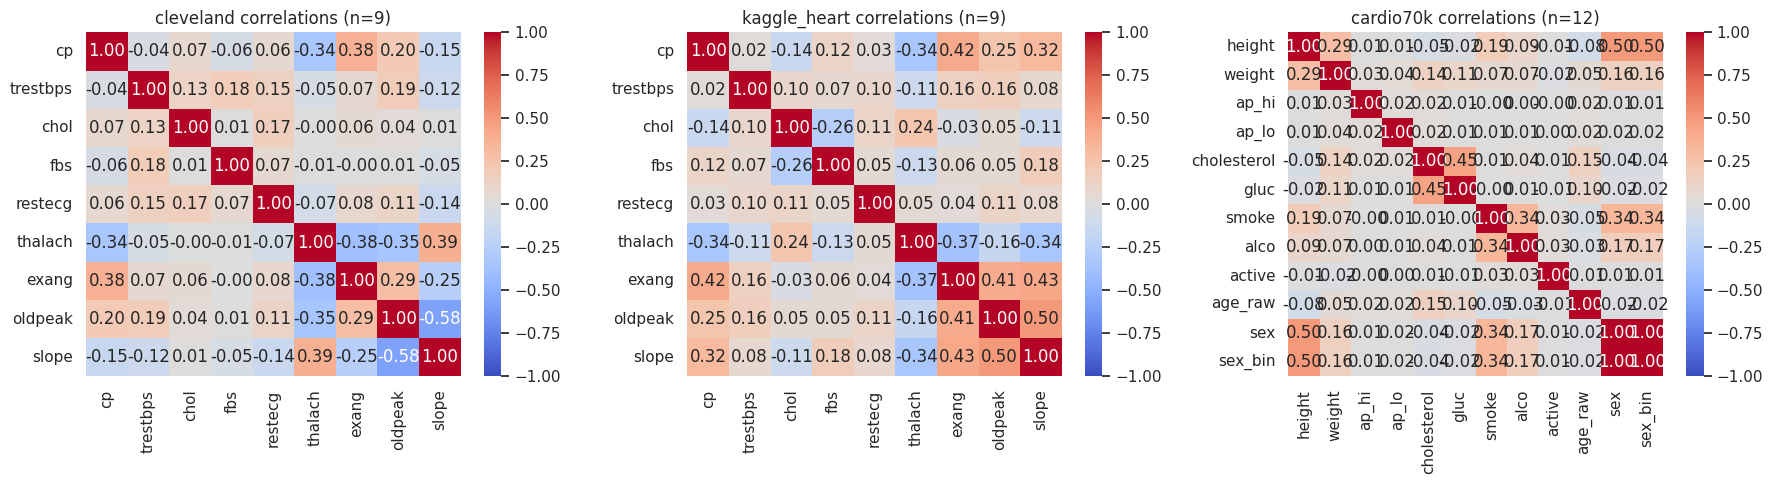

In [21]:
def numeric_for_corr(df: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    cols = {}
    for feature in features:
        series = df[feature] if feature in df.columns else None
        if series is None:
            continue
        if feature in CATEGORY_MAPPINGS:
            mapped = standardize_category(feature, series)
            codes = pd.Series(mapped).cat.codes.replace(-1, np.nan)
            cols[feature] = codes
        else:
            cols[feature] = pd.to_numeric(series, errors="coerce")
    numeric = pd.DataFrame(cols)
    numeric = numeric.dropna(axis=1, how="all")
    numeric = numeric.loc[:, numeric.nunique(dropna=True) > 1]
    return numeric

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
corr_targets = [("cleveland", cleveland_df, plot_features), ("kaggle_heart", kaggle_df, plot_features)]
cardio_df = raw.get("cardio70k")
if cardio_df is not None:
    cardio_features = [c for c in cardio_df.columns if c != TARGET_COL]
    corr_targets.append(("cardio70k", cardio_df, cardio_features))
else:
    corr_targets.append(("cardio70k", pd.DataFrame(), []))

for idx, (name, df, features) in enumerate(corr_targets):
    numeric = numeric_for_corr(df, features) if not df.empty else pd.DataFrame()
    if numeric.shape[1] < 2:
        axes[idx].set_title(f"{name} correlations (insufficient numeric features)")
        axes[idx].axis("off")
        continue
    corr = numeric.corr(numeric_only=True)
    sns.heatmap(
        corr,
        ax=axes[idx],
        cmap="coolwarm",
        center=0,
        vmin=-1,
        vmax=1,
        annot=True,
        fmt=".2f",
        cbar=True,
    )
    axes[idx].set_title(f"{name} correlations (n={corr.shape[0]})")
plt.tight_layout()

## Clustering and similarity view (raw)
Explore potential latent groups beyond age/sex using a simple PCA + KMeans view.

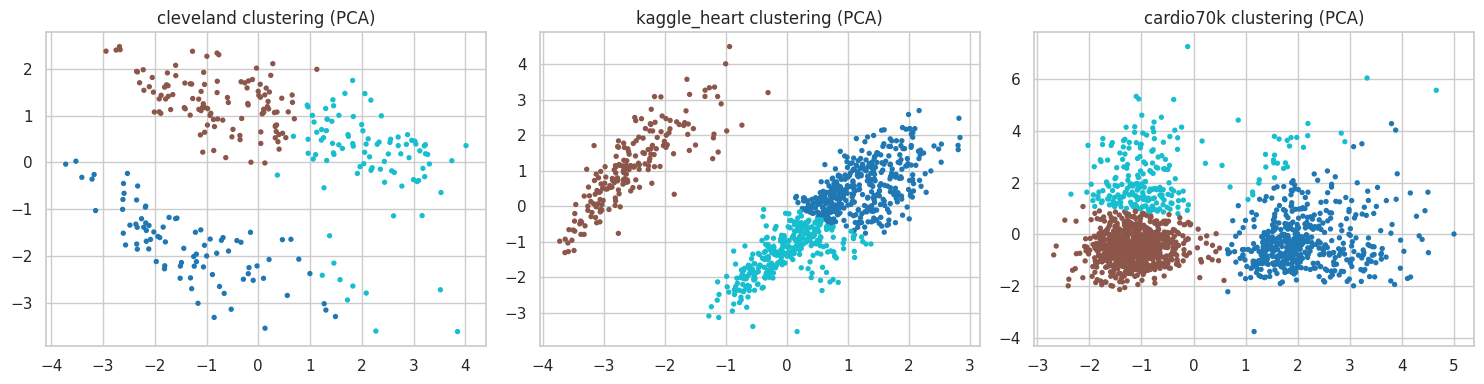

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, name in enumerate(DATASETS):
    df = raw[name]
    numeric = df.select_dtypes(include=[np.number]).drop(columns=[TARGET_COL], errors="ignore")
    numeric = numeric.dropna(axis=0)
    if numeric.empty:
        axes[idx].set_title(f"{name} clustering (no data)")
        continue
    sample = numeric.sample(n=min(1500, len(numeric)), random_state=42)
    scaled = StandardScaler().fit_transform(sample)
    pca = PCA(n_components=2, random_state=42)
    emb = pca.fit_transform(scaled)
    kmeans = KMeans(n_clusters=3, n_init=10, random_state=42)
    clusters = kmeans.fit_predict(emb)
    axes[idx].scatter(emb[:, 0], emb[:, 1], c=clusters, s=8, cmap="tab10")
    axes[idx].set_title(f"{name} clustering (PCA)")
plt.tight_layout()

## Cardio70k-specific features
Focus on features unique to the 70k dataset and their distributions.

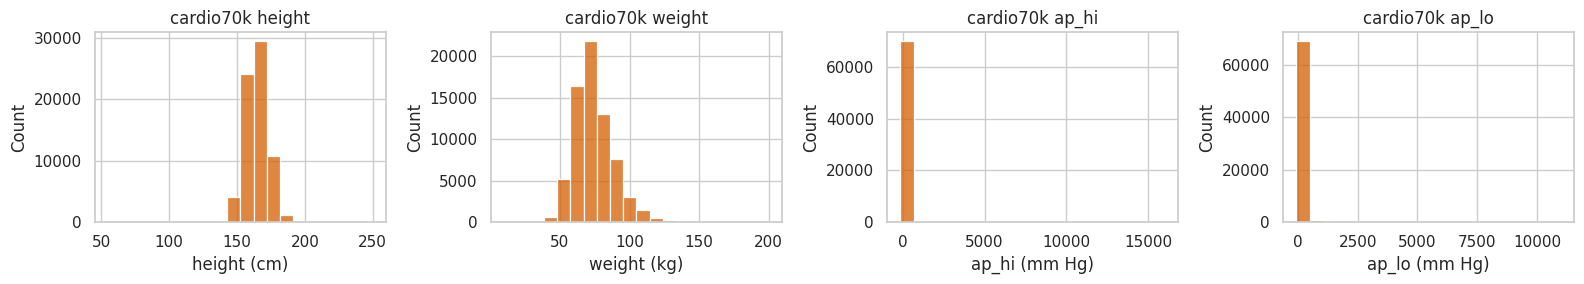

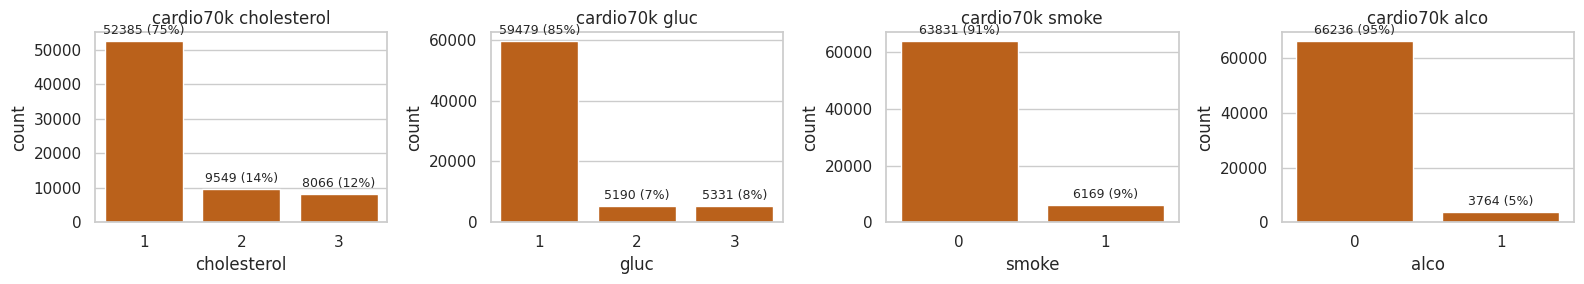

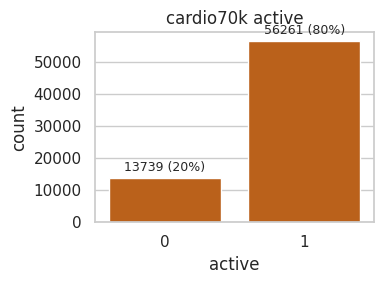

In [23]:
cardio_df = raw.get("cardio70k")
if cardio_df is not None:
    cardio_unique = list(feature_map.get("dataset_specific", {}).get("cardio70k", {}).keys())
    cardio_unique = [f for f in cardio_unique if f in cardio_df.columns]
    if cardio_unique:
        batch_size = 4
        batches = [cardio_unique[i:i + batch_size] for i in range(0, len(cardio_unique), batch_size)]
        for batch in batches:
            fig, axes = plt.subplots(1, len(batch), figsize=(4 * len(batch), 3))
            if len(batch) == 1:
                axes = [axes]
            for idx, feature in enumerate(batch):
                series = cardio_df[feature]
                if series.nunique() <= 5:
                    counts = series.value_counts().sort_index()
                    sns.barplot(x=counts.index.astype(str), y=counts.values, ax=axes[idx], color=PALETTE_DATASET["cardio70k"])
                    axes[idx].set_ylabel("count")
                    add_bar_labels(ax=axes[idx], total=counts.sum())
                else:
                    sns.histplot(series, bins=20, ax=axes[idx], color=PALETTE_DATASET["cardio70k"])
                    unit = UNITS.get(feature)
                    if unit:
                        axes[idx].set_xlabel(f"{feature} ({unit})")
                axes[idx].set_title(f"cardio70k {feature}")
            plt.tight_layout()
    else:
        print("No cardio70k-specific features found in raw data.")

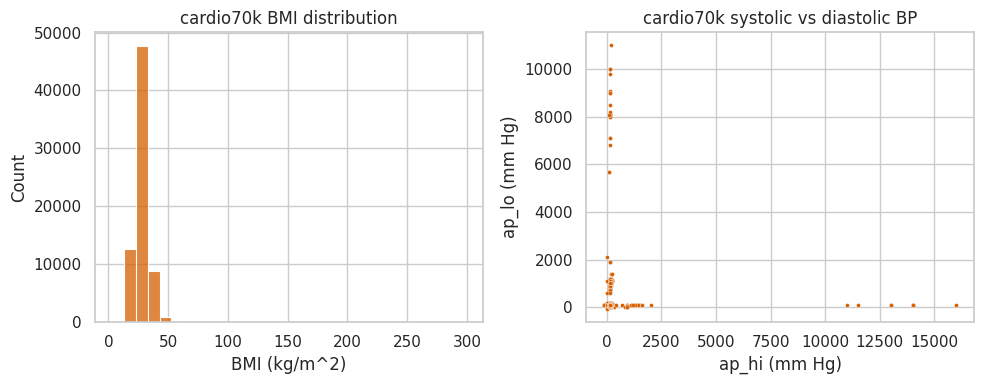

In [24]:
if cardio_df is not None and {"height", "weight"}.issubset(cardio_df.columns):
    bmi = cardio_df["weight"] / (cardio_df["height"] / 100) ** 2
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    sns.histplot(bmi, bins=30, ax=axes[0], color=PALETTE_DATASET["cardio70k"])
    axes[0].set_title("cardio70k BMI distribution")
    axes[0].set_xlabel("BMI (kg/m^2)")
    if {"ap_hi", "ap_lo"}.issubset(cardio_df.columns):
        sns.scatterplot(x=cardio_df["ap_hi"], y=cardio_df["ap_lo"], ax=axes[1], s=8, color=PALETTE_DATASET["cardio70k"])
        axes[1].set_title("cardio70k systolic vs diastolic BP")
        axes[1].set_xlabel("ap_hi (mm Hg)")
        axes[1].set_ylabel("ap_lo (mm Hg)")
    plt.tight_layout()

## Baseline and fairness outputs (latest run)
Load baseline and fairness summaries from the most recent run if available.

In [25]:
def resolve_latest_run(results_dir: Path) -> Path | None:
    latest_txt = results_dir / "latest_run.txt"
    if latest_txt.exists():
        run_id = latest_txt.read_text().strip()
        run_dir = results_dir / "runs" / run_id
        if run_dir.exists():
            return run_dir
    return None

latest_run = resolve_latest_run(RESULTS_DIR)
latest_run

PosixPath('/home/miguel/Desktop/Dissertacao/Code/FairXAI/results/cardiac/runs/run_20260211_135106_368_17790_cba542')

In [26]:
if latest_run is None:
    print("No latest run found under results/cardiac/runs.")
else:
    baseline_dir = latest_run / "baseline"
    baseline_jsons = list(baseline_dir.glob("**/*baseline_metrics*.json"))
    print(f"Found {len(baseline_jsons)} baseline metric files")
    if baseline_jsons:
        rows = []
        for path in baseline_jsons:
            with open(path, "r") as f:
                data = json.load(f)
            dataset = data.get("dataset") or path.stem
            metrics = data.get("metrics", {})
            rows.append({"dataset": dataset, **metrics})
        display(pd.DataFrame(rows))
    fairness_dir = baseline_dir / "fairness"
    fairness_csvs = list(fairness_dir.glob("*_fairness_summary.csv"))
    if fairness_csvs:
        summaries = []
        for path in fairness_csvs:
            df = pd.read_csv(path)
            df["dataset"] = path.stem.replace("_fairness_summary", "")
            summaries.append(df)
        display(pd.concat(summaries, ignore_index=True))
    print("Note: cardio70k baseline may be missing until baseline training supports it.")

Found 0 baseline metric files


,sensitive_attribute,metric,is_fair,max_difference,tpr_max_difference,fpr_max_difference,split,dataset
0,age_group_cat,demographic_parity,False,0.607843,NaN,NaN,train,cleveland
1,age_group_cat,equalized_odds,False,NaN,1.000000,0.238095,train,cleveland
2,age_group_cat,equal_opportunity,False,1.000000,NaN,NaN,train,cleveland
3,age_group_cat,predictive_parity,False,1.000000,NaN,NaN,train,cleveland
4,sex_cat,demographic_parity,False,0.329870,NaN,NaN,train,cleveland
5,sex_cat,equalized_odds,False,NaN,0.184295,0.081290,train,cleveland
6,sex_cat,equal_opportunity,False,0.184295,NaN,NaN,train,cleveland
7,sex_cat,predictive_parity,False,0.138462,NaN,NaN,train,cleveland
8,age_group_cat,demographic_parity,False,0.590909,NaN,NaN,test,cleveland
9,age_group_cat,equalized_odds,False,NaN,0.833333,0.333333,test,cleveland


Note: cardio70k baseline may be missing until baseline training supports it.


## Key observations
Summary points based on the comparisons above.

- Sex distribution varies across datasets; cardio70k shows a different balance from the clinical cohorts.
- Age ranges are broadly similar in years, but cardio70k requires day-to-year conversion to align with other datasets.
- Several clinical features show distribution shifts between Cleveland and Kaggle, confirmed by KS-test results for numeric features.
- Cardio70k introduces lifestyle and exam variables (e.g., activity, alcohol, blood pressure) not present in the clinical datasets.